In [1]:
import os, sys
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression

In [9]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set style
plt.style.use('seaborn-v0_8-paper')

# set sizes
SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 7

rc('font', size=MEDIUM_SIZE)          # controls default text sizes
rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# set font
rc('font', **{'family':'serif','serif':['Arial']})
rc('svg', **{'fonttype':'none'})

# one more change to axes and tick widths
rc('axes', **{'linewidth': 0.5, 'labelpad': 2.5})

rc('xtick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})
rc('ytick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})

In [2]:
path_gene_expr = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_promoter_2000_8000/tko_zero_ratio_cutoffs.bed'
df_sc_filt = pd.read_csv(path_gene_expr, sep='\t')

In [3]:
# bulk gene counts
paths = [
    '/home/data/Shared/shared_datasets/rna_seq/data/GSE126958/GSM3662267_HUES64_WT_RNAseq.txt',
    '/home/data/Shared/shared_datasets/rna_seq/data/GSE126958/GSM3662269_HUES8_WT_RNAseq.txt',
    '/home/data/Shared/shared_datasets/rna_seq/data/GSE126958/GSM3662270_HUES8_TKO_RNAseq.txt',
    '/home/data/Shared/shared_datasets/rna_seq/data/GSE126958/GSM3662268_HUES64_DKO_RNAseq.txt',
]

suffixes = [
    '_hues64_bulk_wt',
    '_hues8_bulk_wt',
    '_hues8_bulk_tko',
    '_hues64_bulk_dko'
]

In [4]:
def load_bulk(path, suffix):
    
    df = pd.read_csv(path, sep='\t')
    
    # remove duplicates by getting the maximum value
    # duplicates are due to different gene isoforms...
    # the maximum is probably the one which is correct for the cell type
    df.sort_values(by=['Gene Name', 'TPM'], inplace=True)
    
    df.index = df['Gene Name']
    df = df[~df.index.duplicated(keep='last')]
    
    df = df[['TPM', 'FPKM']]
    
    df['log_TPM'] = np.log2(df['TPM'])
    df['log_FPKM'] = np.log2(df['FPKM'])
    
    df = df.add_suffix(suffix)

    return df

In [5]:
# This makes a wide dataframe
df_list = [load_bulk(path, suffix) for path, suffix in zip(paths, suffixes)]
df_bulk_concat = pd.concat(df_list, axis=1)

df_bulk_concat['bulk_tko_wt_hues8_lfc_tpm'] = df_bulk_concat['log_TPM_hues8_bulk_tko'] - df_bulk_concat['log_TPM_hues8_bulk_wt']
df_bulk_concat['bulk_tko_wt_hues64_lfc_tpm'] = df_bulk_concat['log_TPM_hues8_bulk_tko'] - df_bulk_concat['log_TPM_hues64_bulk_wt']

/home/nlaszik/venvs/methylation/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nlaszik/venvs/methylation/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nlaszik/venvs/methylation/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nlaszik/venvs/methylation/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nlaszik/venvs/methylation/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nlaszik/venvs/methy

In [6]:
df_all_concat = pd.merge(df_bulk_concat, df_sc_filt, left_index=True, right_on='gene')

In [7]:
df_short = df_all_concat[['log_mean_wt', 'log_TPM_hues64_bulk_wt']]

df_short.replace([np.inf, -np.inf], np.nan, inplace=True)
df_short.dropna(inplace=True)

X = df_short['log_mean_wt'].to_numpy().reshape(-1,1)
y = df_short['log_TPM_hues64_bulk_wt'].to_numpy().reshape(-1,1)

reg = LinearRegression().fit(X, y)
slope = reg.coef_
intercept = reg.intercept_

/tmp/ipykernel_666382/3924528978.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_short.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_666382/3924528978.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_short.dropna(inplace=True)


In [8]:
df_all_concat_short = df_all_concat[['log_TPM_hues64_bulk_wt', 'log_TPM_hues8_bulk_wt', 'log_TPM_hues8_bulk_tko', 'log_mean_hues64_sc_wt_1', 'log_mean_hues8_sc_tko_1']]

# we add the intercept, it's just the assumed scaling between TPM and the scRNA-seq measurement
df_all_concat_short['log_mean_hues64_sc_wt_1'] = df_all_concat_short['log_mean_hues64_sc_wt_1'] + intercept
df_all_concat_short['log_mean_hues8_sc_tko_1'] = df_all_concat_short['log_mean_hues8_sc_tko_1'] + intercept


KeyError: "['log_mean_hues64_sc_wt_1', 'log_mean_hues8_sc_tko_1'] not in index"

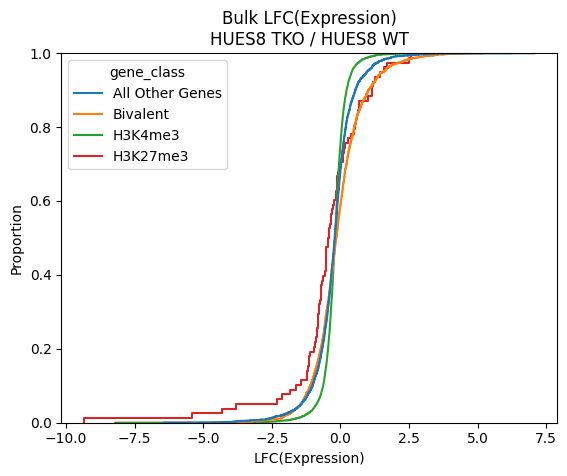

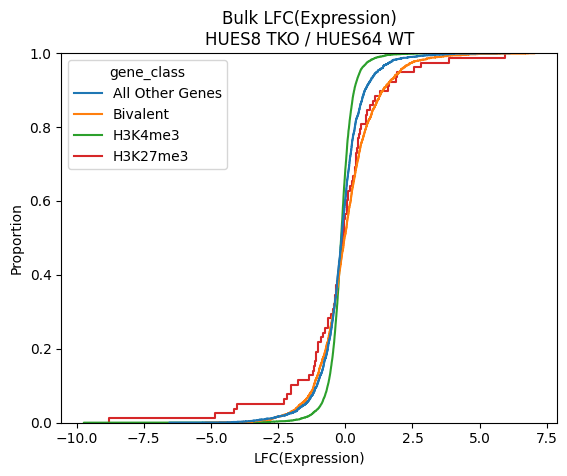

In [15]:
sns.ecdfplot(data=df_all_concat, x='bulk_tko_wt_hues8_lfc_tpm', hue='gene_class')
plt.title('Bulk LFC(Expression)\nHUES8 TKO / HUES8 WT')
plt.xlabel('LFC(Expression)')
plt.show()

sns.ecdfplot(data=df_all_concat, x='bulk_tko_wt_hues64_lfc_tpm', hue='gene_class')
plt.title('Bulk LFC(Expression)\nHUES8 TKO / HUES64 WT')
plt.xlabel('LFC(Expression)')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


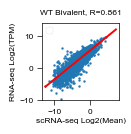

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


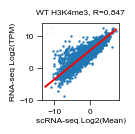

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


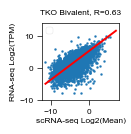

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


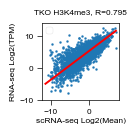

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


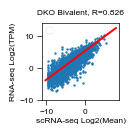

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


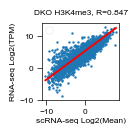

In [12]:
pairs = [
    ['log_mean_wt', 'log_TPM_hues64_bulk_wt'],
    ['log_mean_tko', 'log_TPM_hues8_bulk_tko'],
    ['log_mean_dko', 'log_TPM_hues64_bulk_dko'],
]

gene_classes = list(set(df_all_concat['Promoter Class']))

for pair in pairs:
    
    for gene_class in gene_classes:

        if gene_class == 'H3K27me3' or gene_class == 'All Other Genes':
            continue

        df_all_concat_filt = df_all_concat.loc[df_all_concat['Promoter Class'] == gene_class]

        df_all_concat_filt = df_all_concat_filt[pair]
        df_all_concat_filt.replace([np.inf, -np.inf], np.nan, inplace=True)
        df_all_concat_filt.dropna(inplace=True)
    
        fig, ax = plt.subplots(figsize=(1,1))
        
        res = pearsonr(df_all_concat_filt[pair[0]], df_all_concat_filt[pair[1]])
        r_val = round(res[0], 3)
        ax.scatter(df_all_concat_filt[pair[0]], df_all_concat_filt[pair[1]], s=2)
    
        xs = np.array([min(df_all_concat[pair[0]]), max(df_all_concat[pair[0]])])
        ys = slope * xs + intercept
        
        ax.plot(xs, ys[0], 'r')

        state = pair[0].split('_')[-1].upper()
        
        ax.set_title(f'{state} {gene_class}, R={r_val}')
        ax.set_xlabel('scRNA-seq Log2(Mean)')
        ax.set_ylabel('RNA-seq Log2(TPM)')

        ax.set_ylim([-10,14])
        
        plt.legend()
        plt.savefig(f'figures/{gene_class}_{pair[0]}_{pair[1]}.svg')
        plt.show()
        plt.close()

In [75]:
df_1_for_concat['dataset'] = 'Bulk HUES64 WT'
df_2_for_concat['dataset'] = 'Bulk HUES8 WT'
df_3_for_concat['dataset'] = 'Bulk HUES8 TKO'
df_concat = pd.concat([df_1_for_concat, df_2_for_concat, df_3_for_concat])
print(df_concat)

                   TPM      FPKM         dataset
Gene Name                                       
5S_rRNA       0.142008  0.061545  Bulk HUES64 WT
7SK           0.938114  0.406572  Bulk HUES64 WT
A1BG          6.267479  2.716281  Bulk HUES64 WT
A1BG-AS1      1.559044  0.675679  Bulk HUES64 WT
A1CF          0.000000  0.000000  Bulk HUES64 WT
...                ...       ...             ...
snoZ5         0.000000  0.000000  Bulk HUES8 TKO
snoZ6         0.207670  0.093198  Bulk HUES8 TKO
snosnR60_Z15  0.000000  0.000000  Bulk HUES8 TKO
snosnR66      0.000000  0.000000  Bulk HUES8 TKO
yR211F11.2    0.246000  0.110399  Bulk HUES8 TKO

[167295 rows x 3 columns]


In [25]:
def broken_barplot(df_concat, genes, ylim_1, ylim_2):
    
    f, (ax1, ax2) = plt.subplots(ncols=1, nrows=2, sharex=True)
    df_filtered = df_concat.loc[df_concat['Gene Name'].isin(genes)]

    ax1 = sns.barplot(data=df_filtered, x='Gene Name', y='TPM', hue='dataset', order=genes, ax=ax1)
    ax2 = sns.barplot(data=df_filtered, x='Gene Name', y='TPM', hue='dataset', order=genes, ax=ax2)

    ax1.set_ylim(ylim_1[0], ylim_1[1])
    ax2.set_ylim(ylim_2[0], ylim_2[1])

    # the upper part does not need its own x axis as it shares one with the lower part
    ax1.get_xaxis().set_visible(False)

    # by default, each part will get its own "Latency in ms" label, but we want to set a common for the whole figure
    # first, remove the y label for both subplots
    ax1.set_ylabel("")
    ax2.set_ylabel("")
    # then, set a new label on the plot (basically just a piece of text) and move it to where it makes sense (requires trial and error)
    f.text(0.05, 0.55, "TPM", va="center", rotation="vertical")

    # by default, seaborn also gives each subplot its own legend, which makes no sense at all
    # soe remove both default legends first
    ax1.get_legend().remove()
    ax2.get_legend().remove()
    # then create a new legend and put it to the side of the figure (also requires trial and error)
    ax2.legend(loc=(1.025, 0.5), title="dataset")

    # let's put some ticks on the top of the upper part and bottom of the lower part for style
    ax1.xaxis.tick_top()
    ax2.xaxis.tick_bottom()

    # finally, adjust everything a bit to make it prettier (this just moves everything, best to try and iterate)
    f.subplots_adjust(left=0.15, right=0.85, bottom=0.15, top=0.85)

    ax1.set_title('Charlton RNA-seq')
    
    plt.xticks(rotation=45, ha='right')
    plt.show()
    plt.close()

/tmp/ipykernel_3668558/4005630844.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['log_TPM'] = np.log2(df_filtered['TPM'])


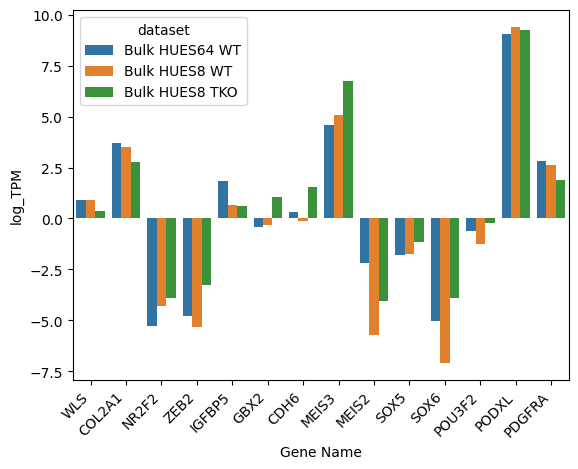

/tmp/ipykernel_3668558/4005630844.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_concat_filtered['Gene Name'] = df_all_concat_filtered.index


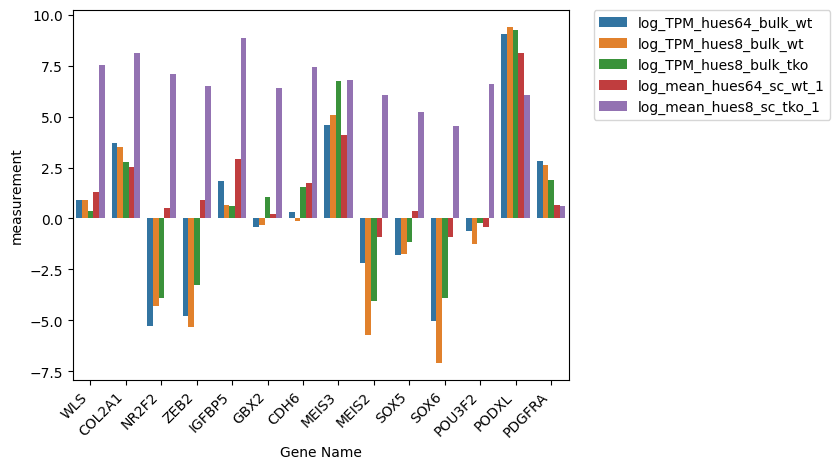

ZNRF2
ZNRF2P1
ZNRF3
ZP3
ZRANB1
ZRANB2
ZRANB3
ZSCAN10
ZSCAN12
ZSCAN16
ZSCAN16-AS1
ZSCAN18
ZSCAN2
ZSCAN20
ZSCAN21
ZSCAN22
ZSCAN23
ZSCAN25
ZSCAN29
ZSCAN30
ZSCAN31
ZSCAN32
ZSCAN5A
ZSCAN9
ZSWIM1
ZSWIM3
ZSWIM4
ZSWIM5
ZSWIM6
ZSWIM7
ZSWIM8
ZW10
ZWILCH
ZWINT
ZXDC
ZYG11A
ZYG11B
ZYX
ZZEF1
ZZZ3

A1BG
A1BG-AS1
A2M-AS1
A4GALT
AAAS
AACS
AADAT
AAGAB
AAK1
AAMDC
AAMP
AAR2
AARD
AARS2
AARSD1
AASDH
AASDHPPT
AASS
AATF
ABAT
ABCA1
ABCA11P
ABCA2
ABCA3
ABCA5
ABCA7
ABCB10
ABCB4
ABCB8
ABCB9
ABCC1
ABCC10
ABCC3
ABCC4
ABCC5
ABCC6
ABCC8
ABCD3
ABCD4
ABCE1
ABCF2
ABCF3
ABCG1
ABCG2
ABHD10
ABHD11
ABHD12
ABHD12B
ABHD13
ABHD14A
ABHD14B
ABHD15
ABHD17A
ABHD17B
ABHD17C
ABHD2
ABHD3
ABHD4
ABHD5
ABHD6
ABHD8
ABI1
ABI2
ABI3
ABL1
ABL2
ABLIM1
ABLIM2
ABR
ABRACL
ABT1
ABTB1
ABTB2
ACAA1
ACAA2
ACACA
ACACB
ACAD10
ACAD11
ACAD8
ACAD9
ACADM
ACADS
ACADSB
ACADVL
ACAP1
ACAP2
ACAP3
ACAT1
ACAT2
ACBD3
ACBD4
ACBD5
ACBD6
ACBD7
ACCS
ACD
ACER2
ACER3
ACHE


In [63]:
genes = ['WLS', 'COL2A1', 'PRTG', 'NR2F2', 'ZEB2', 'IGFBP5', 'PLAGL1', 'NR2F1', 'GBX2', 'CDH6', 'NETO2', 'CNTFR', 'RFX4', 'MEIS3', 'MEIS2', 'DUSP6', 'FAM89B', 'FRZB', 'FZD2', 'GREB1L']

genes = ['WLS', 'COL2A1', 'NR2F2', 'ZEB2', 'IGFBP5', 'GBX2', 'CDH6', 'MEIS3', 'MEIS2', 'SOX5', 'SOX6', 'POU3F2', 'PODXL', 'PDGFRA']

#genes = ['POU3F2', 'NR2F2', 'NEFM', 'LIX1', 'CDH6', 'SOX17', 'PODXL', 'PDX1']
#genes = ['POU5F1', 'POU3F2', 'NR2F2', 'NEFM', 'LIX1', 'CDH6']

ylim_1 = [1000, 1500]
ylim_2 = [0, 25]
#broken_barplot(df_concat, genes, ylim_1, ylim_2)

df_filtered = df_concat.loc[df_concat.index.isin(genes)]

df_filtered['log_TPM'] = np.log2(df_filtered['TPM'])

sns.barplot(data=df_filtered, x='Gene Name', y='log_TPM', hue='dataset', order=genes)
plt.xticks(rotation=45, ha='right')
plt.show()
plt.close()

df_all_concat_filtered = df_all_concat_short.loc[df_all_concat_short.index.isin(genes)]
df_all_concat_filtered['Gene Name'] = df_all_concat_filtered.index

df_long = pd.melt(df_all_concat_filtered, 
                  id_vars=['Gene Name'],  # Columns to keep as is
                  var_name='dataset',              # Name for the new column containing original column names
                  value_name='measurement')        # Name for the new column containing the values

sns.barplot(data=df_long, x='Gene Name', y='measurement', hue='dataset', order=genes)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.xticks(rotation=45, ha='right')
plt.show()
plt.close()


print('\n'.join(df_all_concat_short.tail(40).index))

print()

print('\n'.join(df_all_concat_short.head(100).index))
